# Solution 3A: Cross-Sectional Standardization
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

df = pd.read_parquet("merged.parquet")
df = df[df["month"] >= "2023-01"].copy()
print(f"Loaded: {len(df):,} rows, {df['ticker'].nunique()} tickers")

FEATURES = ["momentum", "lag_month", "pb", "roe", "grossmargin",
            "assetturnover", "leverage", "asset_growth", "gp_to_assets"]

Loaded: 103,931 rows, 3866 tickers


## 1. Z-scores and ranks

In [2]:
# Z-scores
for var in ["momentum", "roe", "gp_to_assets"]:
    df[f"{var}_z"] = df.groupby("month")[var].transform(
        lambda x: (x - x.mean()) / x.std()
    )

sample_months = sorted(df["month"].unique())[3:6]
print("Z-score verification (should be mean~0, std~1):")
for m in sample_months:
    sub = df[df["month"] == m]
    print(f"  {m}:")
    for var in ["momentum", "roe", "gp_to_assets"]:
        print(f"    {var:15s}: mean={sub[f'{var}_z'].mean():.6f}, std={sub[f'{var}_z'].std():.6f}")

Z-score verification (should be mean~0, std~1):
  2023-04:
    momentum       : mean=-0.000000, std=1.000000
    roe            : mean=0.000000, std=1.000000
    gp_to_assets   : mean=-0.000000, std=1.000000
  2023-05:
    momentum       : mean=0.000000, std=1.000000
    roe            : mean=0.000000, std=1.000000
    gp_to_assets   : mean=-0.000000, std=1.000000
  2023-06:
    momentum       : mean=-0.000000, std=1.000000
    roe            : mean=0.000000, std=1.000000
    gp_to_assets   : mean=0.000000, std=1.000000


In [3]:
# Ranks
for var in ["momentum", "roe", "gp_to_assets"]:
    df[f"{var}_rank"] = df.groupby("month")[var].transform(lambda x: x.rank(pct=True))

print("Rank verification (should be mean~0.5):")
for m in sample_months:
    sub = df[df["month"] == m]
    for var in ["momentum", "roe", "gp_to_assets"]:
        print(f"  {m} {var}: mean rank = {sub[f'{var}_rank'].mean():.4f}")

Rank verification (should be mean~0.5):
  2023-04 momentum: mean rank = 0.5002
  2023-04 roe: mean rank = 0.5002
  2023-04 gp_to_assets: mean rank = 0.5002
  2023-05 momentum: mean rank = 0.5002
  2023-05 roe: mean rank = 0.5002
  2023-05 gp_to_assets: mean rank = 0.5002
  2023-06 momentum: mean rank = 0.5002
  2023-06 roe: mean rank = 0.5002
  2023-06 gp_to_assets: mean rank = 0.5002


## 2. Distribution comparison

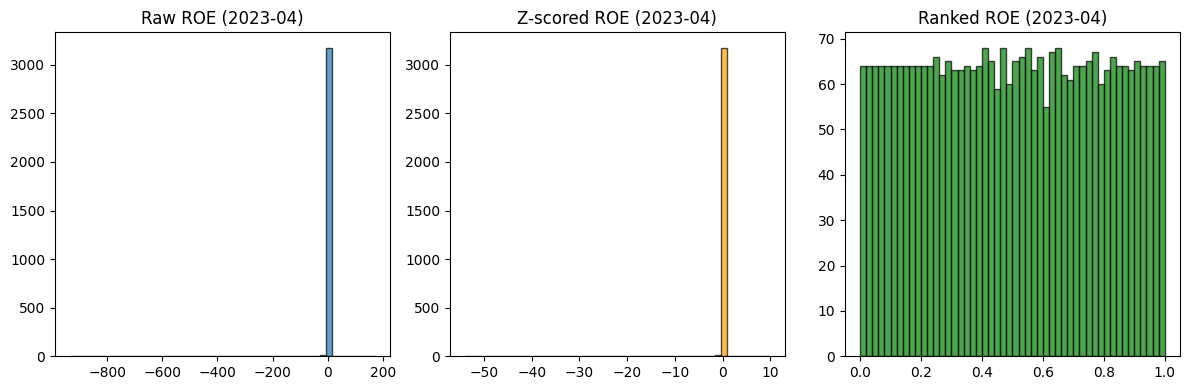

In [4]:
sample_month = sample_months[0]
sub = df[df["month"] == sample_month]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(sub["roe"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title(f"Raw ROE ({sample_month})")
axes[1].hist(sub["roe_z"], bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_title(f"Z-scored ROE ({sample_month})")
axes[2].hist(sub["roe"].rank(pct=True), bins=50, edgecolor="black", alpha=0.7, color="green")
axes[2].set_title(f"Ranked ROE ({sample_month})")
plt.tight_layout()
plt.show()

The **ranked** transformation best handles outliers because it maps all values to a uniform distribution on [0, 1], eliminating the influence of extreme values.

## 3-4. Rank all features and target

In [5]:
for feat in FEATURES:
    df[f"{feat}_rank"] = df.groupby("month")[feat].transform(lambda x: x.rank(pct=True))
df["ret_rank"] = df.groupby("month")["return"].transform(lambda x: x.rank(pct=True))

print("Feature ranks and target rank computed.")
print(f"  Mean ret_rank: {df['ret_rank'].mean():.4f} (should be ~0.5)")

Feature ranks and target rank computed.
  Mean ret_rank: 0.5002 (should be ~0.5)
